# Unrestricted Hartree Fock Challenges
This notebook will exemplify some issues in the development of the UHF and what/how fixes were implemented.

In [1]:
from pyscf import gto, scf
import numpy as np
from Dev.CSUHF import CS_UHF_ContextClass, CS_UHF
from py_mods.src.SCF.RHF import plot_map
import matplotlib.pyplot as plt

## Incorrect Li SCF convergence
This example shows how a flawed guess can lead to errors. In this particular case, with a $H_{core}$ guess, the DIIS gets stuck in an incorrect minimum, and converges to a wrong state. However, if we let the regular SCF continue direvtly it bounces to the correct minimum.

In [2]:
# pyscf data
mol_He = gto.M(
    atom='  Li 0 0 0; ', 
    spin=1,
    charge=0, 
    basis='aug-cc-pvqz'
)

kin = mol_He.intor('int1e_kin')
vnuc = mol_He.intor('int1e_nuc')
overlap = mol_He.intor('int1e_ovlp')
eri = mol_He.intor('int2e')

rhf_He = scf.UHF(mol_He)

e_He = rhf_He.kernel()
e_elec = rhf_He.energy_elec()

print(e_elec)

converged SCF energy = -7.43271871704646  <S^2> = 0.75001472  2S+1 = 2.0000147
(np.float64(-7.432718717046457), np.float64(2.2810037415636426))


In [3]:
# Preparation of the context and calculation
Li_context = CS_UHF_ContextClass(overlap, kin, vnuc, eri, n_electrons=3)
Li_context.max_iter = 300
Li_context.conv_type = 'DIIS'
Li_context.p_guess = 'core'
Li_context.verbose = False
Li_context.threshold = 1E-12

In [4]:
# Li_UHF_results = CS_UHF(Li_context)
# print(f'Converged: {Li_UHF_results.converged} in {Li_UHF_results.iterations}')
# print(f'Final energy: {Li_UHF_results.E_UHF}')
# print(f'Error in Final energy: {Li_UHF_results.E_UHF-e_elec[0]}')

Which is not correct, as it has converged to an incorrect minimum. To fix this problem, we have introduced a RHF guess, that generates a RHF of this system or the cation (to have even electrons) and then starts the UHF calculation from this density:

In [5]:
# Li_context.p_guess = 'RHF'
# Li_correct_UHF_results = CS_UHF(Li_context)
# print(f'Converged: {Li_correct_UHF_results.converged} in {Li_correct_UHF_results.iterations}')
# print(f'Final energy: {Li_correct_UHF_results.E_UHF}')
# print(f'Error in Final energy: {Li_correct_UHF_results.E_UHF-e_elec[0]}')

# Dissociations 
A simple dissociation. Chose atoms, basis and number of electrons here:  

In [6]:
# change here to see different curves. 
n_points = 20
element_1 = 'H'
element_2 = 'H'
basis = 'aug-cc-pvdz'
n_elec = 2

In [7]:
distances = np.linspace(0.3, 15, n_points)
RHF_eners = np.zeros_like(distances)
for i, dist in enumerate(distances):
    mol_He = gto.M(
        atom=f'  {element_1} 0 0 0; {element_2} {dist} 0 0', 
        spin=0,
        charge=0, 
        basis=basis
    )

    kin = mol_He.intor('int1e_kin')
    vnuc = mol_He.intor('int1e_nuc')
    overlap = mol_He.intor('int1e_ovlp')
    eri = mol_He.intor('int2e')

    rhf_He = scf.RHF(mol_He)

    e_He = rhf_He.kernel()
    e_elec = rhf_He.energy_elec()

    RHF_eners[i] = e_elec[0]


converged SCF energy = -0.615684850088793
converged SCF energy = -1.0868742432517
converged SCF energy = -0.946277494426816
converged SCF energy = -0.860054548787112
converged SCF energy = -0.812677939016801
converged SCF energy = -0.786459962020824
converged SCF energy = -0.771378968441063
converged SCF energy = -0.761981736861012
converged SCF energy = -0.75556007260286
converged SCF energy = -0.750829765958827
converged SCF energy = -0.747158913558217
converged SCF energy = -0.744202814520786
converged SCF energy = -0.741754275382603
converged SCF energy = -0.739682736655671
converged SCF energy = -0.737902717986053
converged SCF energy = -0.736355186688669
converged SCF energy = -0.734997037806549
converged SCF energy = -0.733795401221222
converged SCF energy = -0.732724872015896
converged SCF energy = -0.731764888039896


In [8]:
UHF_eners = np.zeros_like(distances)
for i, dist in enumerate(distances):
    mol = gto.M(
        atom=f'  {element_1} 0 0 0; {element_2} {dist} 0 0', 
        spin=0,
        charge=0, 
        basis=basis,
    )

    mf = scf.UHF(mol,)

    dm_alpha, dm_beta = mf.get_init_guess()
    
    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    UHF_eners[i] = e_elec[0]

converged SCF energy = -0.615684850089083  <S^2> = 3.5527137e-15  2S+1 = 1
converged SCF energy = -1.0868742432491  <S^2> = 1.2587709e-11  2S+1 = 1
converged SCF energy = -0.946277494426826  <S^2> = 2.6514346e-12  2S+1 = 1
converged SCF energy = -0.86005454877603  <S^2> = 7.6249007e-11  2S+1 = 1
converged SCF energy = -0.812677939014913  <S^2> = 1.8163249e-11  2S+1 = 1
converged SCF energy = -0.786459962020547  <S^2> = 3.0371261e-12  2S+1 = 1
converged SCF energy = -0.771378968440902  <S^2> = 1.8454127e-12  2S+1 = 1
converged SCF energy = -0.761981736860906  <S^2> = 1.2210233e-12  2S+1 = 1
converged SCF energy = -0.755560072602684  <S^2> = 1.9682034e-12  2S+1 = 1
converged SCF energy = -0.750829765958764  <S^2> = 6.9810824e-13  2S+1 = 1
converged SCF energy = -0.7471589135582  <S^2> = 2.0583535e-13  2S+1 = 1
converged SCF energy = -0.74420281452083  <S^2> = 5.4845017e-14  2S+1 = 1
converged SCF energy = -0.741754275383291  <S^2> = 9.9633635e-12  2S+1 = 1
converged SCF energy = -0.73968

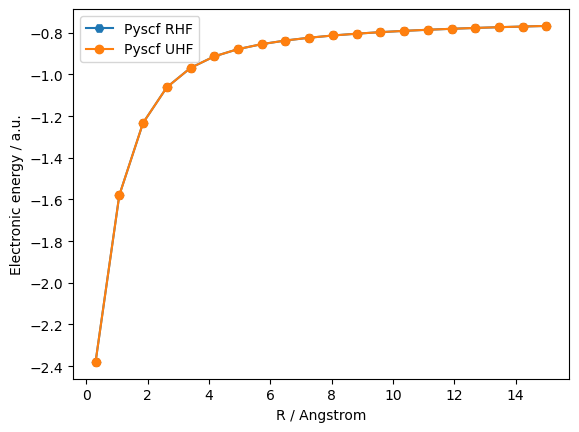

In [9]:
plt.plot(distances, RHF_eners, label='Pyscf RHF', marker='H')
plt.plot(distances, UHF_eners, label='Pyscf UHF', marker='o')
plt.xlabel('R / Angstrom')
plt.ylabel('Electronic energy / a.u.')
plt.legend()
plt.show()

And we can see that there is no notable difference. This is because it is necessary to break the symmetry of the alpha and beta density matrices. This is done by setting to zero the beta density of the 1s and 2s orbitals in the H case. 

In [10]:
UHF_eners = np.zeros_like(distances)
for i, dist in enumerate(distances):
    mol = gto.M(
        atom=f'  {element_1} 0 0 0; {element_2} {dist} 0 0', 
        spin=0,
        charge=0, 
        basis=basis,
    )

    kin = mol_He.intor('int1e_kin')
    vnuc = mol_He.intor('int1e_nuc')
    overlap = mol_He.intor('int1e_ovlp')
    eri = mol_He.intor('int2e')

    mf = scf.UHF(mol,)

    dm_alpha, dm_beta = mf.get_init_guess()
    dm_beta[:n_elec,:n_elec] = 0
    dm = (dm_alpha,dm_beta)

    
    e_He = mf.kernel(dm,)
    e_elec = mf.energy_elec()

    UHF_eners[i] = e_elec[0]

converged SCF energy = -0.615684850088437  <S^2> = 1.5805135e-12  2S+1 = 1
converged SCF energy = -1.08687424325166  <S^2> = 1.3082868e-12  2S+1 = 1
converged SCF energy = -1.00580091704966  <S^2> = 0.84777113  2S+1 = 2.0954915
converged SCF energy = -0.999207562431889  <S^2> = 0.98400238  2S+1 = 2.2217132
converged SCF energy = -0.998710787409532  <S^2> = 0.99835787  2S+1 = 2.2345987
converged SCF energy = -0.998673446192841  <S^2> = 0.99984167  2S+1 = 2.2359264
converged SCF energy = -0.998669562384602  <S^2> = 0.99998596  2S+1 = 2.2360554
converged SCF energy = -0.998668790970804  <S^2> = 0.99999883  2S+1 = 2.2360669
converged SCF energy = -0.998668688001578  <S^2> = 0.9999999  2S+1 = 2.2360679
converged SCF energy = -0.998668641627554  <S^2> = 0.99999999  2S+1 = 2.236068
converged SCF energy = -0.998668636515557  <S^2> = 1  2S+1 = 2.236068
converged SCF energy = -0.998668634954247  <S^2> = 1  2S+1 = 2.236068
converged SCF energy = -0.998668632659118  <S^2> = 1  2S+1 = 2.236068
conv

And we can see that there is a difference in the dissociation curve, as one would expect in the unrestricted case. 

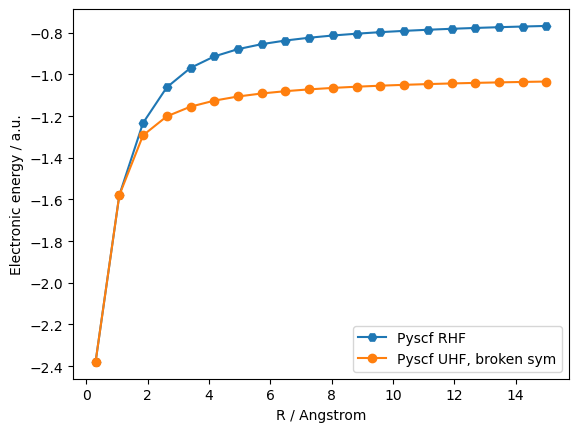

In [11]:
plt.plot(distances, RHF_eners, label='Pyscf RHF', marker='H')
plt.plot(distances, UHF_eners, label='Pyscf UHF, broken sym', marker='o')
plt.xlabel('R / Angstrom')
plt.ylabel('Electronic energy / a.u.')
plt.legend()
plt.show()

However, up to now, the guess for the SCF has been to use the core Hamiltonian. Using this approach directly results in no symmetry breaking, as the density matrix is composed of zeros in the guess. 

Therefore, in order to be able to break the symmetry, it is necessary a non-zero guess. In the current implementation here, we combine the RHF and UHF to start with a few iterations of the RHF in order to get a better guess of the density and then start the UHF loop from this density. 

We will compare now the densities between the pyscf formulation and this approach. 

converged SCF energy = -0.998668631839391  <S^2> = 1  2S+1 = 2.236068


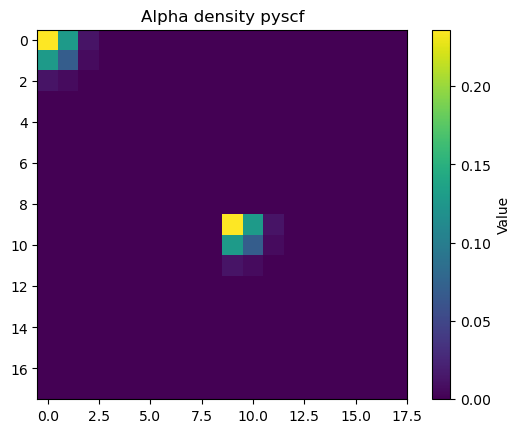

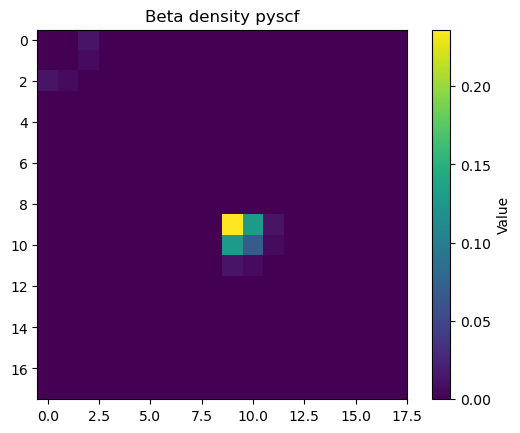

In [12]:
mol = gto.M(
    atom=f'  {element_1} 0 0 0; {element_2} 10 0 0', 
    spin=0,
    charge=0, 
    basis=basis,
)

kin = mol.intor('int1e_kin')
vnuc = mol.intor('int1e_nuc')
overlap = mol.intor('int1e_ovlp')
eri = mol.intor('int2e')


mf = scf.UHF(mol,)

dm_alpha, dm_beta = mf.get_init_guess()
dm_beta[:n_elec,:n_elec] = 0

dm = (dm_alpha,dm_beta)
mf.kernel(dm)

plot_map(dm_alpha, title='Alpha density pyscf')
plot_map(dm_beta, title='Beta density pyscf')

With the regular core guess

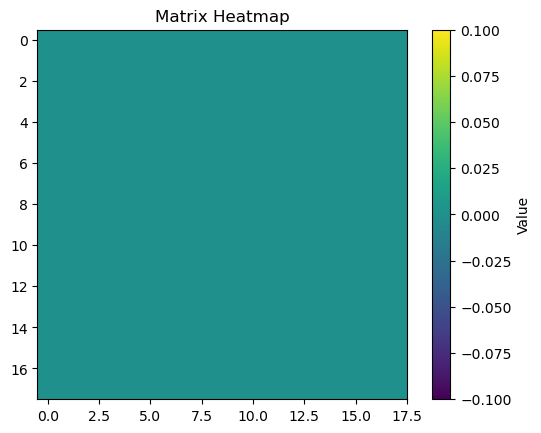

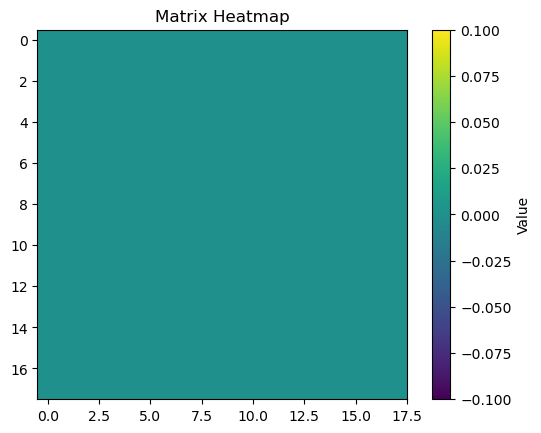

In [13]:
context = CS_UHF_ContextClass(overlap, kin, vnuc, eri, n_electrons=n_elec, max_iter=1)

CS_UHF_results = CS_UHF(context)

plot_map(CS_UHF_results.P_guess_alpha.real)
plot_map(CS_UHF_results.P_guess_beta.real)

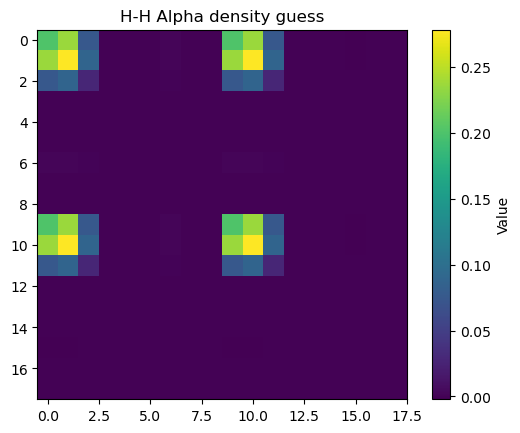

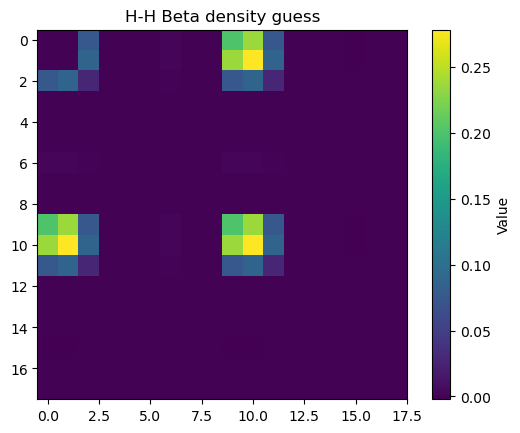

In [14]:
context = CS_UHF_ContextClass(overlap, kin, vnuc, eri, n_electrons=n_elec, break_symm=True, max_iter=50, p_guess='RHF')

CS_UHF_results = CS_UHF(context)

plot_map(CS_UHF_results.P_guess_alpha.real, title=f'{element_1}-{element_2} Alpha density guess')
plot_map(CS_UHF_results.P_guess_beta.real, title=f'{element_1}-{element_2} Beta density guess')

And the final densities:

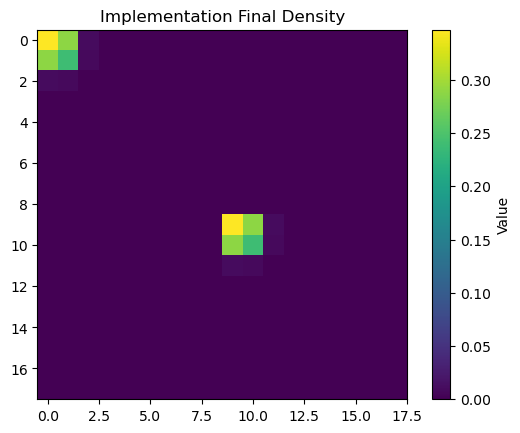

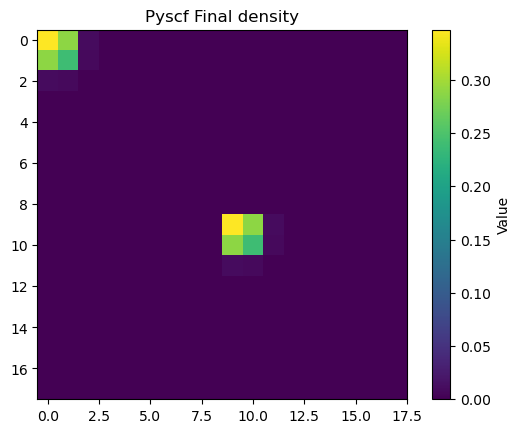

2.0000000000000018
1.9999999999999998


In [15]:
plot_map(CS_UHF_results.P_total.real, title='Implementation Final Density')
plot_map(mf.make_rdm1()[0] + mf.make_rdm1()[1], title='Pyscf Final density')
print(np.trace(CS_UHF_results.P_total.real @ CS_UHF_results.context.S))
print(np.trace((mf.make_rdm1()[0] + mf.make_rdm1()[1]) @ CS_UHF_results.context.S))

## Final dissociation curves
Here we can see the final dissociation curves using this `guess+bsymm` approach. It can be seen that even though in cases such as $HF$ the results are different to the pyscf ones, in both cases convergence is not achieved at longer distances. However, while pyscf seems to oscillate between the RHF and UHF, the implemented UHF presents the expected UHF tendency (even though it is not converged at these points).

In [16]:
Imp_RHF_eners = np.zeros_like(distances)
Imp_RHF_eners_core_guess = np.zeros_like(distances)
for i, dist in enumerate(distances):
    mol = gto.M(
        atom=f'  {element_1} 0 0 0; {element_2} {dist} 0 0', 
        spin=0,
        charge=0, 
        basis=basis
    )

    kin = mol.intor('int1e_kin')
    vnuc = mol.intor('int1e_nuc')
    overlap = mol.intor('int1e_ovlp')
    eri = mol.intor('int2e')

    context = CS_UHF_ContextClass(overlap, kin, vnuc, eri, n_electrons=n_elec, p_guess='RHF', break_symm=True, max_iter=50)
    CS_UHF_results = CS_UHF(context)
    Imp_RHF_eners[i] = CS_UHF_results.E_UHF.real

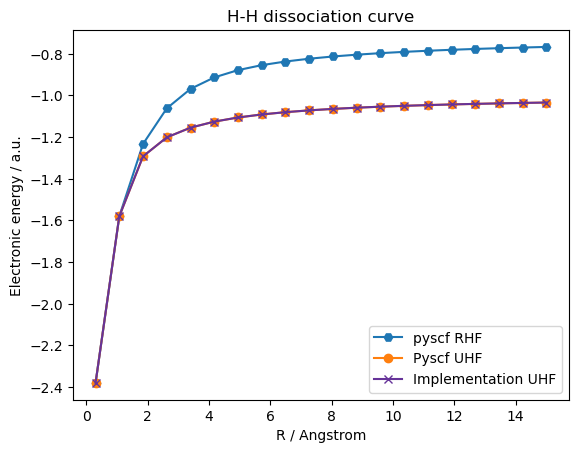

In [17]:
plt.plot(distances, RHF_eners, label='pyscf RHF', marker='H')
plt.plot(distances, UHF_eners, label='Pyscf UHF', marker='o')
plt.plot(distances, Imp_RHF_eners, label='Implementation UHF', marker='x', c='rebeccapurple')
plt.title(f'{element_1}-{element_2} dissociation curve')
plt.xlabel('R / Angstrom')
plt.ylabel('Electronic energy / a.u.')
plt.legend()
plt.show()